LINEAR REGRESSION MODEL FOR DETERMINING HOUSE PRICES

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder # for scaling and encoding
from sklearn.model_selection import train_test_split

house = pd.read_csv('house_prices_practice.csv')
house

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656
...,...,...,...,...,...,...,...,...,...,...
295,296,1,3495,1,1792,1954,2,5,4978,250604
296,297,5,3438,3,1266,2003,0,1,9373,329906
297,298,6,1992,0,1148,1996,1,1,7907,184623
298,299,3,3722,1,1407,1998,1,1,8097,303345


In [3]:
house.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            300 non-null    int64
 1   OverallQual   300 non-null    int64
 2   GrLivArea     300 non-null    int64
 3   GarageCars    300 non-null    int64
 4   TotalBsmtSF   300 non-null    int64
 5   YearBuilt     300 non-null    int64
 6   FullBath      300 non-null    int64
 7   BedroomAbvGr  300 non-null    int64
 8   LotArea       300 non-null    int64
 9   SalePrice     300 non-null    int64
dtypes: int64(10)
memory usage: 23.6 KB


In [4]:
house.head(10)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656
5,6,10,680,1,2480,1950,2,1,13081,213952
6,7,3,1106,2,1096,1962,1,4,11153,145539
7,8,7,3670,1,437,2000,2,5,4989,350830
8,9,8,1199,2,1653,2005,1,5,14040,275955
9,10,5,1492,1,2175,2011,1,2,11218,211664


In [5]:
# CHECK IF THERE ARE ANY DUPLICATES OR NULL VALUES IN THE COLUMNS
house.duplicated().sum()
house.isnull().sum()

house.index.name='House_No.'
house.head(10)

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
House_No.,,,,,,,,,,
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656
5,6,10,680,1,2480,1950,2,1,13081,213952
6,7,3,1106,2,1096,1962,1,4,11153,145539
7,8,7,3670,1,437,2000,2,5,4989,350830
8,9,8,1199,2,1653,2005,1,5,14040,275955


In [6]:
house.describe()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,86.746758,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,75.750000,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,150.500000,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,225.250000,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,300.000000,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


ANALYTICAL VISUALIZATION FOR EACH FEATURE

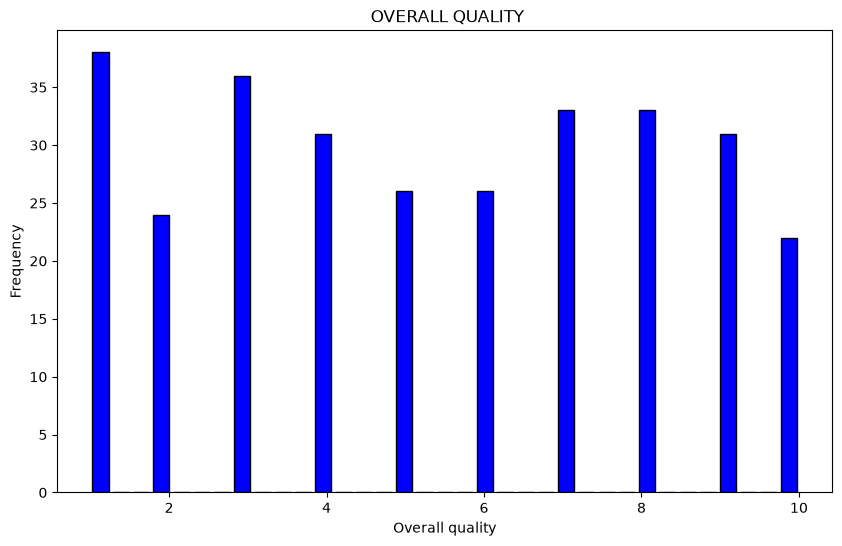

In [13]:
fig = px.histogram(
    house,
    x='OverallQual',
    marginal='box',
    nbins=45,
    title='OVERALL QUALITY'
)
fig.update_layout(bargap=0)
fig.show()

# USING PYPLOT
plt.figure(figsize=(10, 6))
plt.hist(
    house['OverallQual'],
    bins=35,
    color='blue',
    edgecolor='black',
    rwidth=0.8
)

plt.title(' OVERALL QUALITY')
plt.xlabel('Overall quality')
plt.ylabel('Frequency')

plt.show()